# 08 Benchmark Comparison v1

This notebook orchestrates the unified monthly benchmark comparison.

Design choice:
- Keep `run_benchmark_comparison_v1.py` as the production source of truth.
- Use this notebook as a research-facing driver with clear cells for each benchmark.
- Add future benchmarks, such as `rl_overlay_ppo` or `rl_overlay_sac_changepoint`, by adding one loader cell and one entry in the `strategies` dictionary.

Current benchmark set:
- `equal_weight`
- `spy_buy_hold`
- `static_allocator`
- `rl_overlay_sac`

## 1. Imports and shared functions

The notebook imports the production script instead of duplicating benchmark logic. This keeps the notebook convenient for exploration while preserving one implementation path for reproducible runs.

In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from run_benchmark_comparison_v1 import (
    assemble_common_returns,
    build_equal_weight_strategy,
    compute_summary,
    load_spy_returns,
    load_strategy_backtest,
    parse_month_end,
    resolve_path,
    save_monthly_returns,
    save_plots,
    setup_logging,
    write_summary_text,
)

setup_logging()
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

## 2. Configuration

Edit this cell when changing the test window, transaction costs, input files, or output directory. The default window below matches the current benchmark comparison run.

In [3]:
PROJECT_ROOT = Path(".").resolve()

RETURNS_FILE = resolve_path(
    PROJECT_ROOT, "data/panel/monthly_stock_panel_basic_full.parquet"
)
SPY_FILE = resolve_path(PROJECT_ROOT, "data/benchmark/spy_monthly.parquet")
STATIC_BACKTEST_FILE = resolve_path(
    PROJECT_ROOT, "data/allocator/static_allocator_backtest.csv"
)
RL_BACKTEST_FILE = resolve_path(PROJECT_ROOT, "data/rl_overlay_sac/test_backtest.csv")
OUTDIR = resolve_path(PROJECT_ROOT, "data/benchmark_eval")
OUTDIR.mkdir(parents=True, exist_ok=True)

TEST_START = "2020-01"
TEST_END = "2024-11"
COST_BPS = 10.0
SPY_ENTRY_COST_BPS = 0.0

test_start = parse_month_end(TEST_START)
test_end = parse_month_end(TEST_END)

print(f"Project root: {PROJECT_ROOT}")
print(f"Test window: {TEST_START} to {TEST_END}")
print(f"Output directory: {OUTDIR}")

Project root: /Users/lava/Documents/Research/GeorgeMichailidis/portfolio_allocation_rl
Test window: 2020-01 to 2024-11
Output directory: /Users/lava/Documents/Research/GeorgeMichailidis/portfolio_allocation_rl/data/benchmark_eval


## 3. Equal-weight benchmark

The equal-weight strategy is built from the stock-level monthly panel. It uses the month-`t` investable universe, the panel's `target_ret_1m` as the month-`t` to `t+1` realized return, monthly rebalancing, and the same proportional transaction cost model.

In [4]:
equal_weight = build_equal_weight_strategy(
    returns_file=RETURNS_FILE,
    test_start=test_start,
    test_end=test_end,
    cost_bps=COST_BPS,
)

display(equal_weight.head())
display(equal_weight.tail())

2026-05-01 17:32:31 INFO Building equal-weight baseline from: /Users/lava/Documents/Research/GeorgeMichailidis/portfolio_allocation_rl/data/panel/monthly_stock_panel_basic_full.parquet
2026-05-01 17:32:31 INFO Using in_sp500_t == 1 as the investable-universe filter.


,month_end,return,turnover,gross_return,cost,n_assets
0,2020-01-31,-0.019567,1.000000,-0.018567,0.001000,442
1,2020-02-29,-0.090586,0.066490,-0.090520,0.000066,443
2,2020-03-31,-0.181960,0.052397,-0.181907,0.000052,442
3,2020-04-30,0.150333,0.151212,0.150485,0.000151,441
4,2020-05-31,0.051190,0.087783,0.051278,0.000088,442


,month_end,return,turnover,gross_return,cost,n_assets
54,2024-07-31,0.044110,0.054141,0.044164,0.000054,445
55,2024-08-31,0.021746,0.063265,0.021809,0.000063,445
56,2024-09-30,0.022325,0.054619,0.022380,0.000055,442
57,2024-10-31,-0.015937,0.055014,-0.015882,0.000055,445
58,2024-11-30,0.063085,0.061302,0.063146,0.000061,444


## 4. SPY buy-and-hold benchmark

SPY is loaded from `data/benchmark/spy_monthly.parquet` and uses the CRSP/WRDS `ret` column. There is no monthly rebalance. The optional one-time entry cost is applied later during the common-month assembly step.

In [5]:
spy_buy_hold = load_spy_returns(SPY_FILE)

display(spy_buy_hold.head())
display(spy_buy_hold.tail())

2026-05-01 17:32:31 INFO Loading SPY benchmark: /Users/lava/Documents/Research/GeorgeMichailidis/portfolio_allocation_rl/data/benchmark/spy_monthly.parquet


,month_end,return,turnover
0,2000-01-31,-0.049362,NaN
1,2000-02-29,-0.015667,NaN
2,2000-03-31,0.096832,NaN
3,2000-04-30,-0.035121,NaN
4,2000-05-31,-0.015723,NaN


,month_end,return,turnover
295,2024-08-31,0.023366,NaN
296,2024-09-30,0.020979,NaN
297,2024-10-31,-0.008924,NaN
298,2024-11-30,0.059634,NaN
299,2024-12-31,-0.024072,NaN


## 5. Static allocator benchmark

The static allocator is loaded from its existing backtest output. The loader uses `net_return` when available, so this benchmark keeps the transaction-cost treatment already computed by that strategy.

In [6]:
static_allocator = load_strategy_backtest(
    STATIC_BACKTEST_FILE,
    strategy_name="static_allocator",
)

display(static_allocator.head())
display(static_allocator.tail())

2026-05-01 17:32:31 INFO Loading static_allocator backtest: /Users/lava/Documents/Research/GeorgeMichailidis/portfolio_allocation_rl/data/allocator/static_allocator_backtest.csv


,month_end,return,turnover
0,2005-12-31,0.012080,1.774144
1,2006-01-31,0.014953,0.384139
2,2006-02-28,0.008769,0.235843
3,2006-03-31,-0.015619,0.246619
4,2006-04-30,-0.017061,0.172051


,month_end,return,turnover
223,2024-07-31,0.070189,0.063929
224,2024-08-31,0.034866,0.061799
225,2024-09-30,-0.039326,0.284512
226,2024-10-31,0.066655,0.442008
227,2024-11-30,-0.065372,0.119563


## 6. RL overlay SAC benchmark

The SAC overlay is loaded from its existing test backtest output. As with the static allocator, the loader uses `net_return` when available.

In [7]:
rl_overlay_sac = load_strategy_backtest(
    RL_BACKTEST_FILE,
    strategy_name="rl_overlay_sac",
)

display(rl_overlay_sac.head())
display(rl_overlay_sac.tail())

2026-05-01 17:32:31 INFO Loading rl_overlay_sac backtest: /Users/lava/Documents/Research/GeorgeMichailidis/portfolio_allocation_rl/data/rl_overlay_sac/test_backtest.csv


,month_end,return,turnover
0,2020-01-31,-0.081858,1.221334
1,2020-02-29,-0.103465,0.104734
2,2020-03-31,0.082583,0.353285
3,2020-04-30,0.056177,0.234176
4,2020-05-31,-0.004939,0.087542


,month_end,return,turnover
54,2024-07-31,0.057750,0.000557
55,2024-08-31,0.020046,0.033267
56,2024-09-30,-0.043127,0.196101
57,2024-10-31,0.047554,0.174858
58,2024-11-30,-0.065395,0.049856


## 7. Assemble common monthly return table

This is the key integration point. Every strategy is restricted to the requested test window and then intersected to one common set of months. To add a new benchmark, create its DataFrame with `month_end`, `return`, and optional `turnover`, then add it to this dictionary.

In [8]:
strategies = {
    "equal_weight": equal_weight,
    "spy_buy_hold": spy_buy_hold,
    "static_allocator": static_allocator,
    "rl_overlay_sac": rl_overlay_sac,
}

returns, turnover = assemble_common_returns(
    strategies=strategies,
    test_start=test_start,
    test_end=test_end,
    spy_entry_cost_bps=SPY_ENTRY_COST_BPS,
)

display(returns.head())
display(turnover.head())
print(f"Common months: {len(returns)}")
print(
    f"Common window: {returns['month_end'].min().date()} to {returns['month_end'].max().date()}"
)

2026-05-01 17:32:31 INFO Common test window has 59 months: 2020-01 to 2024-11.


,month_end,equal_weight,spy_buy_hold,static_allocator,rl_overlay_sac
0,2020-01-31,-0.019567,-0.000404,-0.081918,-0.081858
1,2020-02-29,-0.090586,-0.079166,-0.099933,-0.103465
2,2020-03-31,-0.181960,-0.125243,0.074355,0.082583
3,2020-04-30,0.150333,0.126984,0.050578,0.056177
4,2020-05-31,0.051190,0.047645,0.005235,-0.004939


,month_end,equal_weight,spy_buy_hold,static_allocator,rl_overlay_sac
0,2020-01-31,1.000000,NaN,0.411401,1.221334
1,2020-02-29,0.066490,NaN,0.262521,0.104734
2,2020-03-31,0.052397,NaN,0.485176,0.353285
3,2020-04-30,0.151212,NaN,0.333344,0.234176
4,2020-05-31,0.087783,NaN,0.125570,0.087542


Common months: 59
Common window: 2020-01-31 to 2024-11-30


## 8. Performance summary

The summary uses the same metrics as the production script: annualized return, annualized volatility, Sharpe ratio, max drawdown, cumulative return, mean monthly turnover, win rate, and number of months.

In [9]:
summary = compute_summary(returns, turnover)

summary_display = summary.copy()
for col in [
    "annualized_return",
    "annualized_volatility",
    "max_drawdown",
    "cumulative_return",
    "mean_monthly_turnover",
    "win_rate",
]:
    summary_display[col] = summary_display[col].map(
        lambda x: "" if pd.isna(x) else f"{x:.2%}"
    )
summary_display["sharpe_ratio"] = summary_display["sharpe_ratio"].map(
    lambda x: "" if pd.isna(x) else f"{x:.3f}"
)

display(summary_display)

,strategy,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,cumulative_return,mean_monthly_turnover,win_rate,n_months
0,equal_weight,12.70%,20.41%,0.622,-25.61%,80.04%,7.86%,57.63%,59
1,spy_buy_hold,15.28%,18.26%,0.836,-23.92%,101.17%,,64.41%,59
2,static_allocator,7.80%,15.60%,0.500,-12.81%,44.66%,16.27%,59.32%,59
3,rl_overlay_sac,7.80%,15.29%,0.510,-12.17%,44.67%,9.28%,61.02%,59


## 9. Save benchmark outputs

This cell writes the same CSV and TXT artifacts as the command-line script.

In [10]:
monthly_returns_path = OUTDIR / "benchmark_monthly_returns.csv"
summary_csv_path = OUTDIR / "benchmark_summary.csv"
summary_txt_path = OUTDIR / "benchmark_summary.txt"

save_monthly_returns(returns, turnover, monthly_returns_path)
summary.to_csv(summary_csv_path, index=False)
write_summary_text(summary, summary_txt_path)

print(f"Saved: {monthly_returns_path}")
print(f"Saved: {summary_csv_path}")
print(f"Saved: {summary_txt_path}")

2026-05-01 17:32:32 INFO Saved monthly benchmark returns: /Users/lava/Documents/Research/GeorgeMichailidis/portfolio_allocation_rl/data/benchmark_eval/benchmark_monthly_returns.csv
2026-05-01 17:32:32 INFO Saved benchmark summary text: /Users/lava/Documents/Research/GeorgeMichailidis/portfolio_allocation_rl/data/benchmark_eval/benchmark_summary.txt


Saved: /Users/lava/Documents/Research/GeorgeMichailidis/portfolio_allocation_rl/data/benchmark_eval/benchmark_monthly_returns.csv
Saved: /Users/lava/Documents/Research/GeorgeMichailidis/portfolio_allocation_rl/data/benchmark_eval/benchmark_summary.csv
Saved: /Users/lava/Documents/Research/GeorgeMichailidis/portfolio_allocation_rl/data/benchmark_eval/benchmark_summary.txt


## 10. Save plots

The plotting function saves:
- `cumulative_nav_comparison.png`
- `monthly_return_comparison.png`
- `turnover_comparison.png`

In [11]:
save_plots(returns, turnover, OUTDIR)

print(f"Saved plots under: {OUTDIR}")

2026-05-01 17:32:32 INFO Saved cumulative NAV plot: /Users/lava/Documents/Research/GeorgeMichailidis/portfolio_allocation_rl/data/benchmark_eval/cumulative_nav_comparison.png
2026-05-01 17:32:32 INFO Saved monthly return comparison plot: /Users/lava/Documents/Research/GeorgeMichailidis/portfolio_allocation_rl/data/benchmark_eval/monthly_return_comparison.png
2026-05-01 17:32:32 INFO Saved turnover comparison plot: /Users/lava/Documents/Research/GeorgeMichailidis/portfolio_allocation_rl/data/benchmark_eval/turnover_comparison.png


Saved plots under: /Users/lava/Documents/Research/GeorgeMichailidis/portfolio_allocation_rl/data/benchmark_eval


## 11. Quick visual inspection inside notebook

These plots are for notebook review only. The production plot files are saved in the previous cell.

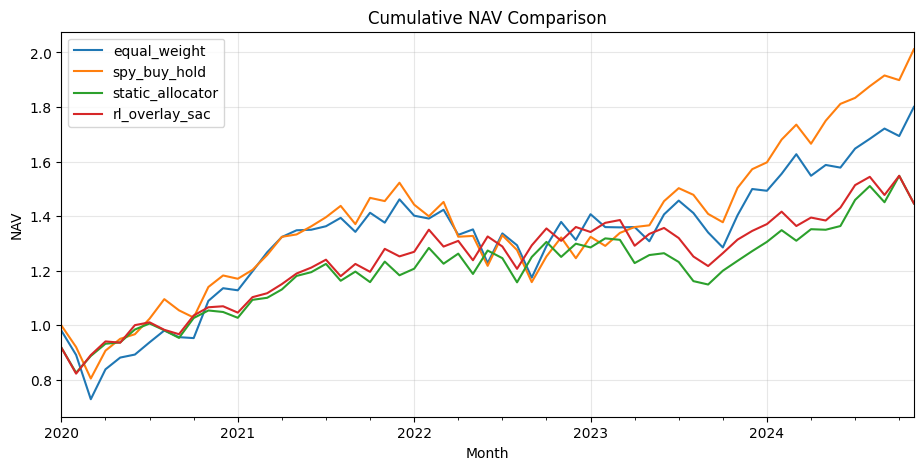

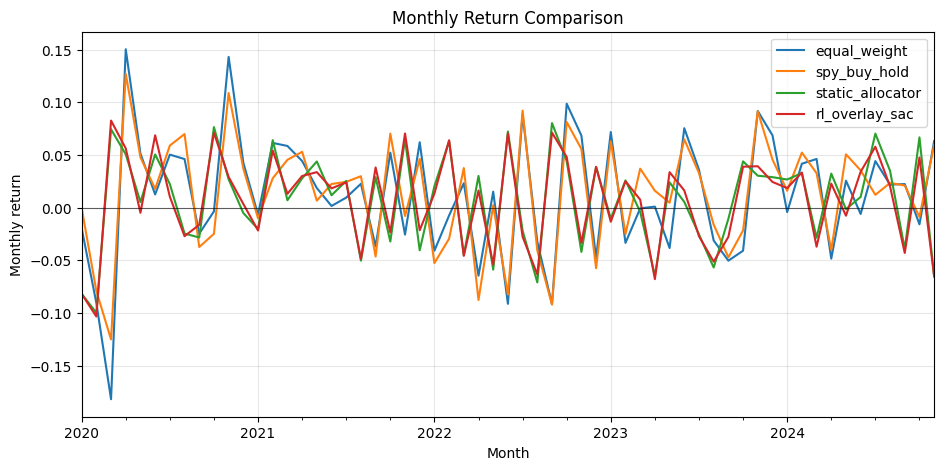

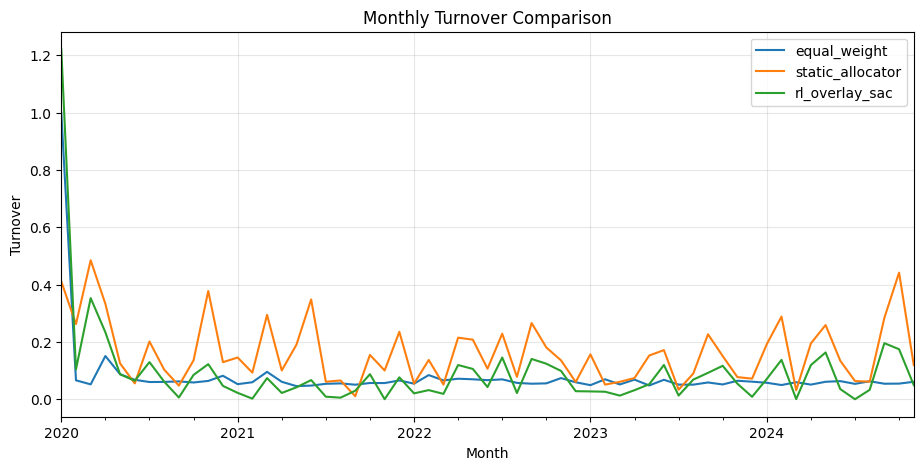

In [12]:
nav = (1.0 + returns.set_index("month_end")).cumprod()
ax = nav.plot(figsize=(11, 5), title="Cumulative NAV Comparison")
ax.set_xlabel("Month")
ax.set_ylabel("NAV")
ax.grid(True, alpha=0.3)
plt.show()

ax = returns.set_index("month_end").plot(
    figsize=(11, 5), title="Monthly Return Comparison"
)
ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.6)
ax.set_xlabel("Month")
ax.set_ylabel("Monthly return")
ax.grid(True, alpha=0.3)
plt.show()

turnover_cols = [
    col
    for col in ["equal_weight", "static_allocator", "rl_overlay_sac"]
    if turnover[col].notna().any()
]
ax = turnover.set_index("month_end")[turnover_cols].plot(
    figsize=(11, 5), title="Monthly Turnover Comparison"
)
ax.set_xlabel("Month")
ax.set_ylabel("Turnover")
ax.grid(True, alpha=0.3)
plt.show()

## 12. Extension pattern for future benchmarks

For `rl_overlay_ppo` or `rl_overlay_sac_changepoint`, the cleanest path is:

1. Save that strategy's backtest with at least `month_end` and `net_return`; include `turnover` if applicable.
2. Add one notebook cell:

```python
rl_overlay_ppo = load_strategy_backtest(
    PROJECT_ROOT / "data/rl_overlay_ppo/test_backtest.csv",
    strategy_name="rl_overlay_ppo",
)
```

3. Add it to `strategies`:

```python
strategies["rl_overlay_ppo"] = rl_overlay_ppo
```

If the new benchmark has a different schema, add a small loader function to `run_benchmark_comparison_v1.py` rather than rewriting logic in the notebook.